In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


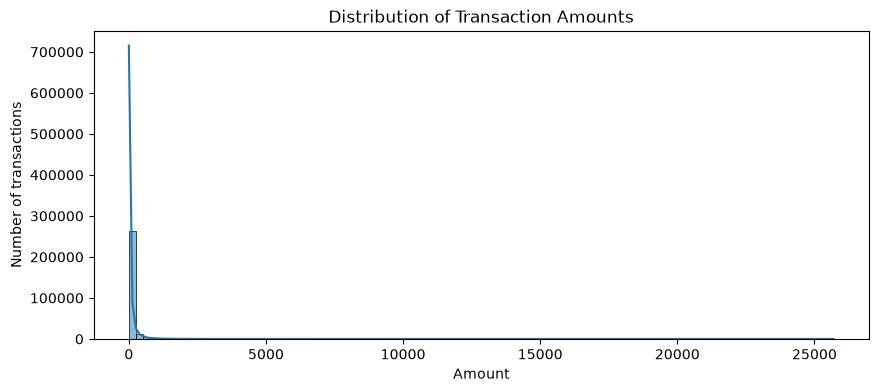

In [4]:


plt.figure(figsize=(10, 4))
sns.histplot(df['Amount'], bins=100, kde=True)
plt.xlabel('Amount')
plt.ylabel('Number of transactions')
plt.title('Distribution of Transaction Amounts')
plt.show()

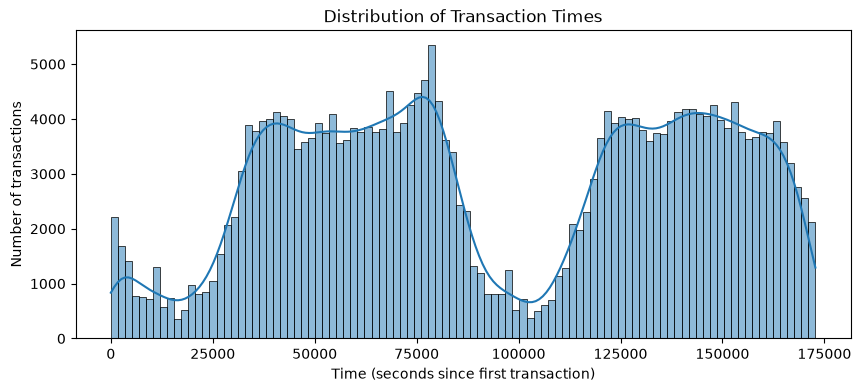

In [5]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Time'], bins=100, kde=True)
plt.xlabel('Time (seconds since first transaction)')
plt.ylabel('Number of transactions')
plt.title('Distribution of Transaction Times')
plt.show()

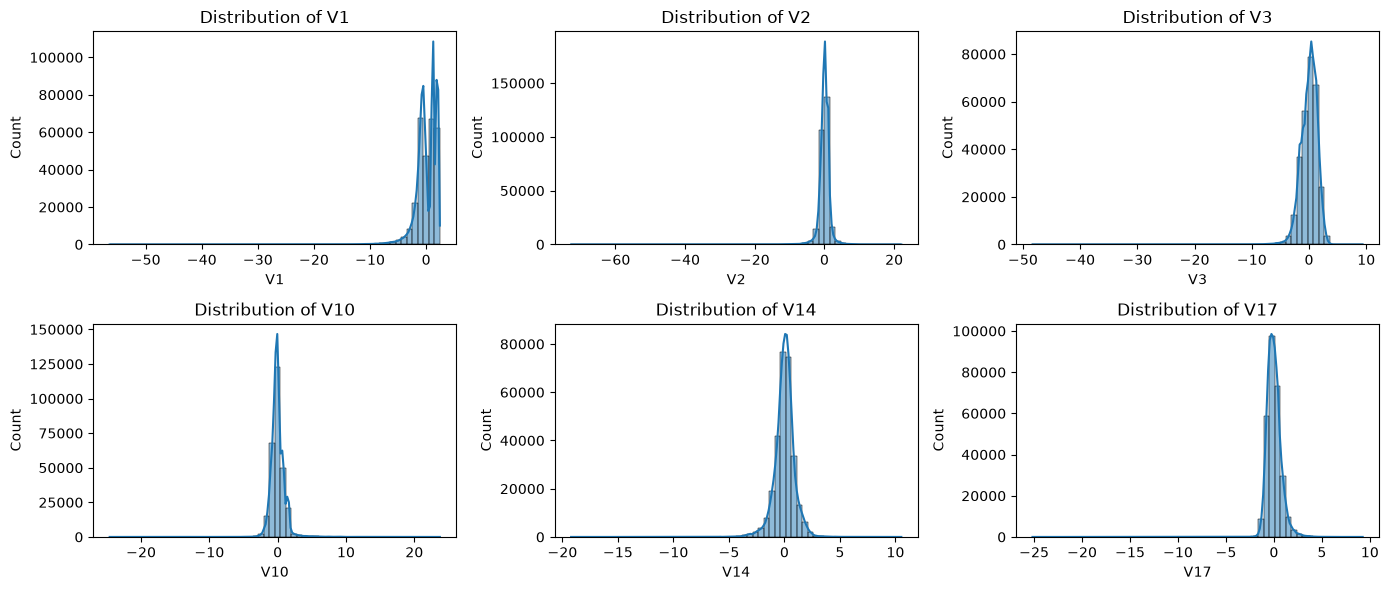

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
features = ['V1', 'V2', 'V3', 'V10', 'V14', 'V17']

for ax, feature in zip(axes.flatten(), features):
    sns.histplot(df[feature], bins=60, kde=True, ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [7]:
duplicated_rows = df[df.duplicated(keep=False)]
print(f"Total duplicate rows: {len(duplicated_rows)}")
print(f"\nFirst few duplicates:")
print(duplicated_rows.head(10))

Total duplicate rows: 1854

First few duplicates:
      Time        V1        V2        V3        V4        V5        V6  \
32    26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
33    26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
34    26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
35    26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
112   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
113   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
114   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
115   74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   
220  145.0 -2.420413  1.947885  0.553646  0.983069 -0.281518  2.408958   
221  145.0 -2.420413  1.947885  0.553646  0.983069 -0.281518  2.408958   

           V7        V8        V9  ...       V21       V22       V23  \
32   0.711206  0.176066 -0.286717  ...  0.046949  0.208105 -0.1

In [8]:
print("Class distribution in duplicated rows:")
print(df[df.duplicated(keep=False)]['Class'].value_counts())

Class distribution in duplicated rows:
Class
0    1822
1      32
Name: count, dtype: int64


In [9]:
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")



Shape after dropping duplicates: (283726, 31)


In [10]:
print(f"\nClass distribution after dropping duplicates:")
print(df['Class'].value_counts())


Class distribution after dropping duplicates:
Class
0    283253
1       473
Name: count, dtype: int64


In [11]:
print(f"\nFraud percentage: {df['Class'].mean() * 100:.4f}%")


Fraud percentage: 0.1667%


In [12]:
print(f"Null values: {df.isnull().sum().sum()}")
print(f"\nZero-amount transactions: {len(df[df['Amount'] == 0])}")
print(f"Class breakdown of $0 transactions:")
print(df[df['Amount'] == 0]['Class'].value_counts())
print(f"\nNegative-amount transactions: {len(df[df['Amount'] < 0])}")

Null values: 0

Zero-amount transactions: 1808
Class breakdown of $0 transactions:
Class
0    1783
1      25
Name: count, dtype: int64

Negative-amount transactions: 0


In [13]:
print(df.dtypes)
print(f"\nAny non-numeric columns: {df.select_dtypes(exclude='number').columns.tolist()}")

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Any non-numeric columns: []


In [14]:
y = df['Class'].copy()
df = df.drop(columns=['Class'])

print(f"df shape (features only): {df.shape}")
print(f"y shape (answer key): {y.shape}")
print(f"Columns remaining in df: {df.columns.tolist()}")

df shape (features only): (283726, 30)
y shape (answer key): (283726,)
Columns remaining in df: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [15]:
df['Hour'] = (df['Time'] / 3600 % 24).astype(int)
df = df.drop(columns=['Time'])

print(f"df shape: {df.shape}")
print(f"\nHour column sample:")
print(df['Hour'].describe())
print(f"\nColumn list: {df.columns.tolist()}")

df shape: (283726, 30)

Hour column sample:
count    283726.000000
mean         14.045646
std           5.834817
min           0.000000
25%          10.000000
50%          15.000000
75%          19.000000
max          23.000000
Name: Hour, dtype: float64

Column list: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour']


In [16]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_scaled = scaler.fit_transform(df)

print(f"Scaled array shape: {df_scaled.shape}")
print(f"\nFirst row (raw):    {df.iloc[0].values[:5]}")
print(f"First row (scaled): {df_scaled[0][:5]}")

Scaled array shape: (283726, 30)

First row (raw):    [-1.35980713 -0.07278117  2.53634674  1.37815522 -0.33832077]
First row (scaled): [-0.61835994 -0.09762245  1.22943358  0.88087785 -0.21877322]


In [17]:
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
print(df_scaled.head())
print(f"\nAmount column stats after scaling:")
print(df_scaled['Amount'].describe())

         V1        V2        V3        V4        V5        V6        V7  \
0 -0.618360 -0.097622  1.229434  0.880878 -0.218773  0.632648  0.176974   
1  0.524849  0.144367 -0.007034  0.295891  0.087159  0.165383 -0.106558   
2 -0.617709 -1.002505  0.831270  0.252882 -0.345402  1.780431  0.668400   
3 -0.442046 -0.177906  0.841592 -0.529031  0.033147  1.305834  0.175202   
4 -0.528050  0.581026  0.714142  0.267510 -0.271669  0.318307  0.491620   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0  0.143677  0.335739  0.186041  ...  0.026861  0.253199 -0.320939  0.032627   
1  0.118241 -0.163546 -0.074543  ... -0.473668 -0.602596  0.363373 -0.479559   
2  0.422384 -1.178892  0.304165  ...  0.669336  0.714327  2.974843 -0.919547   
3  0.665139 -1.075980  0.038703  ... -0.190254 -0.001308 -0.578965 -1.531860   
4 -0.547078  0.701771  0.855554  ...  0.048275  0.739164 -0.408139  0.126231   

        V25       V26       V27       V28    Amount      Hour  
0  0

In [18]:
from sklearn.ensemble import IsolationForest

contamination_rate = y.sum() / len(y)
print(f"Contamination rate: {contamination_rate:.6f}")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate,
    random_state=42
)

iso_forest.fit(df_scaled)
print("Model fitted successfully.")

Contamination rate: 0.001667
Model fitted successfully.


In [19]:
predictions = iso_forest.predict(df_scaled)
anomaly_scores = iso_forest.decision_function(df_scaled)

df['anomaly_prediction'] = predictions
df['anomaly_score'] = anomaly_scores

print(df['anomaly_prediction'].value_counts())
print(f"\nAnomaly score range: {anomaly_scores.min():.4f} to {anomaly_scores.max():.4f}")

anomaly_prediction
 1    283253
-1       473
Name: count, dtype: int64

Anomaly score range: -0.1097 to 0.3207


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (df['anomaly_prediction'] == -1).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred))
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=['Normal', 'Fraud']))

Confusion Matrix:
[[282884    369]
 [   369    104]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    283253
       Fraud       0.22      0.22      0.22       473

    accuracy                           1.00    283726
   macro avg       0.61      0.61      0.61    283726
weighted avg       1.00      1.00      1.00    283726



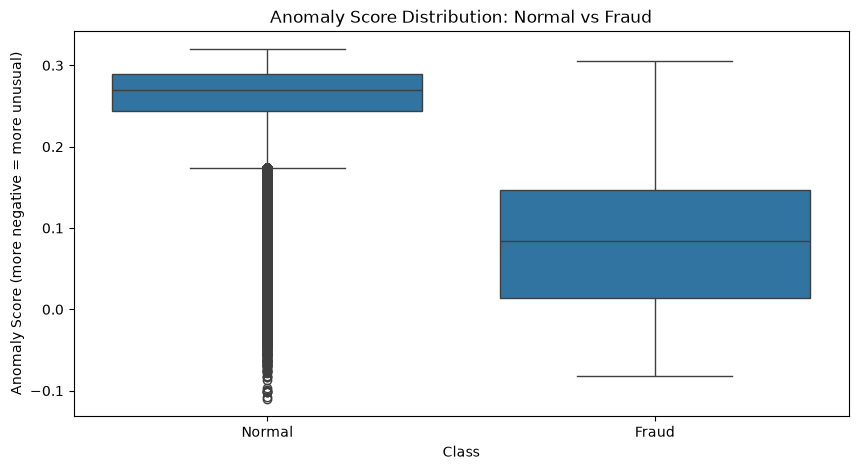

In [21]:
df['Class'] = y.values

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Class', y='anomaly_score')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.title('Anomaly Score Distribution: Normal vs Fraud')
plt.ylabel('Anomaly Score (more negative = more unusual)')
plt.show()

In [22]:
caught_fraud = df[(df['Class'] == 1) & (df['anomaly_prediction'] == -1)]
missed_fraud = df[(df['Class'] == 1) & (df['anomaly_prediction'] == 0)]
missed_fraud = df[(df['Class'] == 1) & (df['anomaly_prediction'] == 1)]

print(f"Caught fraud: {len(caught_fraud)}")
print(f"Missed fraud: {len(missed_fraud)}")

print("\nMean feature values, caught fraud:")
print(caught_fraud[['V14', 'V17', 'V12', 'Amount', 'Hour']].mean())

print("\nMean feature values, missed fraud:")
print(missed_fraud[['V14', 'V17', 'V12', 'Amount', 'Hour']].mean())

Caught fraud: 104
Missed fraud: 369

Mean feature values, caught fraud:
V14      -10.574435
V17      -16.377051
V12      -12.280513
Amount    99.444135
Hour       6.596154
dtype: float64

Mean feature values, missed fraud:
V14        -5.782280
V17        -3.669162
V12        -4.362238
Amount    130.756640
Hour       13.081301
dtype: float64


In [23]:
import joblib

joblib.dump(iso_forest, 'fraud_isolation_forest.joblib')
joblib.dump(scaler, 'fraud_scaler.joblib')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
